In [46]:
import os
import uuid
import getpass
from typing import TypedDict, Annotated, Sequence, List, Tuple, Optional, Any, Union, Literal,  Tuple
import operator
from datetime import date
from IPython.display import display, Markdown, Image
from graphviz import Source
import uuid  

# Langchain specific imports
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import BaseMessage, ToolMessage, HumanMessage, AIMessage, SystemMessage
from langchain.tools import tool
#from langchain_core.pydantic_v1 import BaseModel  # For tool args schema if needed explicitly
from pydantic import BaseModel
from openai import OpenAI
from dotenv import load_dotenv
from langchain_tavily import TavilySearch
from amadeus import Client, ResponseError
from langgraph.prebuilt import ToolNode 

# LangGraph imports (Updated based on recent versions)
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode  # Preferred way to handle tool execution



In [47]:
# Helper function to display markdown nicely
def print_markdown(text):
    """Displays text as Markdown in Jupyter."""
    display(Markdown(text))


In [48]:
  
# This will be used to load the API key from the .env file
load_dotenv()

openai_api_key = os.getenv("OPENAI_API_KEY")
openai_client = OpenAI(api_key = openai_api_key)
print("OpenAI client successfully configured.")

# Let's view the first few characters in the key
print(openai_api_key[:5])

tavily_api_key = os.getenv("TAVILY_API_KEY")
print(f"Tavily Key starts with: {tavily_api_key[:5]}...")

amadeus_api_key = os.getenv("AMADEUS_CLIENT_ID")
amadeus_api_secret = os.getenv("AMADEUS_CLIENT_SECRET")
print(f"Amadeus Key starts with: {amadeus_api_key[:5]}...")
print(f"Amadeus Secret starts with: {amadeus_api_secret[:5]}...")

OpenAI client successfully configured.
sk-pr
Tavily Key starts with: tvly-...
Amadeus Key starts with: 3EIsv...
Amadeus Secret starts with: fIgPR...


In [49]:
tavily = TavilySearch(max_results=3)

@tool
def web_search_tool(query: str):
    """Search the web for sports events, stadium info, or travel tips."""
    return tavily.run(query)


# List of tools for this step
#tools_list_single = [tavily_search_tool]

llm = ChatOpenAI(model = "gpt-4.1-mini", temperature = 0, streaming = True)

print("LangChain OpenAI Chat Model configured.")


# Configure Amadeus Client

amadeus_client = Client(
    client_id = amadeus_api_key,
    client_secret = amadeus_api_secret,
    hostname = "test",  # Start with the test environment
)


LangChain OpenAI Chat Model configured.


In [50]:
# Define the Agent State
class AgentState(TypedDict):
    # AgentState is the name of the dictionary (used to represent the agent's state in the workflow).
    # It has one key: "messages", which holds a list of messages (e.g., from the user, model, or tools).
    # BaseMessage is the type used to represent each message in that list.
    # operator.add tells LangGraph to append new messages to the list during execution.
    messages: Annotated[Sequence[BaseMessage], operator.add]


SYSTEM_JSON_RULES = """
You are a backend API.

You MUST return strictly valid JSON.
You MUST follow the exact schema provided by the user.
If data is missing, return empty arrays.
Do NOT include explanations, markdown, or extra text.
Do NOT wrap JSON in code blocks.
"""



def make_call_model_with_tools(tools: list):
    def call_model_with_tools(state: AgentState):
        print("DEBUG: Entering call_model_with_tools node")
        messages = state["messages"]
        
        # Binds the tools to the language model 
        model_with_tools = llm.bind_tools(tools)

        # Feeds the conversation history (messages) into the model
        response = model_with_tools.invoke(messages)

        # Return the model response as a new message
        return {"messages": [response]}

    return call_model_with_tools


def should_continue(state: AgentState) -> Literal["action", "__end__"]:
    """Determines the next step: continue with tools or end."""
    print("DEBUG: Entering should_continue node")
    last_message = state["messages"][-1]
    
    # Check if the last message is an AIMessage with tool_calls
    if isinstance(last_message, AIMessage) and hasattr(last_message, "tool_calls") and last_message.tool_calls:
        print("DEBUG: Decision: continue (route to action)")
        return "action"  # Route to the node named "action"
    else:
        print("DEBUG: Decision: end (route to END)")
        return END  # Special value indicating the end of the graph



 

def build_graph_one_tool(tools_list):

    # Let's Instantiate ToolNode
    tool_node = ToolNode(tools_list)

    # Define the call_node_fn, which binds the tools to the LLM and calls OpenAI API
    call_node_fn = make_call_model_with_tools(tools_list)       

    # Build the Graph with One Tool using ToolNode
    graph_one_tool = StateGraph(AgentState)

    # Add nodes
    graph_one_tool.add_node("agent", call_node_fn)
    
    # Add the ToolNode instance directly, naming it "action"
    graph_one_tool.add_node("action", tool_node)

    # Set entry point
    graph_one_tool.set_entry_point("agent")

    # Add a conditional edge from the agent
    # The dictionary maps the return value of 'should_continue' ("action" or END)
    # to the name of the next node ("action" or the special END value).
    graph_one_tool.add_conditional_edges(
        "agent",  # Source node name
        should_continue,  # Function to decide the route
        {"action": "action", END: END},  # Mapping: {"decision": "destination_node_name"}
    )

    # Add edge from action (ToolNode) back to agent
    graph_one_tool.add_edge("action", "agent")

    # Compile the graph
    app = graph_one_tool.compile()

    # Visualize
    display(Image(app.get_graph().draw_mermaid_png()))

    return app



def app_call(app, messages):
    # Initialize the state with the provided messages
    initial_state = {
    "messages": [
        SystemMessage(content=SYSTEM_JSON_RULES),
        HumanMessage(content=messages),
    ]
}


    # Invoke the app with the initial state
    final_state = app.invoke(initial_state)

    # Iterate through the messages in the final state
    for i in final_state["messages"]:
        # Print the type of the message in markdown format
        print_markdown(i.type)
        # Print the content of the message in markdown format
        print_markdown(i.content)
        # Print any additional kwargs associated with the message
        if i.additional_kwargs != {}:
            print(i.additional_kwargs)

    # Return the content of the last message and the final state
    return final_state["messages"][-1].content, final_state

@tool
def search_football_events_tool(city: str, date_range: str):
    """
    Finds upcoming football (soccer) matches in a given city and date range.
    Useful for locating Bundesliga or international matches when planning sports travel.
    """
    query = f"football matches in {city} during {date_range}"
    return tavily.run(query)


@tool
def get_stadium_info_tool(stadium_or_city: str):
    """
    Provides stadium information, nearby transport options, and tips for match day travel.
    """
    query = f"{stadium_or_city} football stadium transport train metro nearby attractions"
    return tavily.run(query)



@tool
def search_train_schedule_tool(origin_city: str, destination_city: str, arrival_time: str):
    """
    Searches for train or bus options between two German cities.
    
    origin_city: where you start
    destination_city: where you want to go
    arrival_time: desired arrival time at the stadium (YYYY-MM-DD HH:MM)
    
    Returns: a list of suitable train/bus options.
    """
    query = (
        f"Train or bus schedule from {origin_city} to {destination_city} "
        f"so I arrive by {arrival_time}. Include departure time, duration, and arrival time."
    )
    return tavily.run(query)




@tool
def get_current_date_tool():
    """Returns the current date in 'YYYY-MM-DD' format. Useful for finding flights/hotels relative to today."""
    return date.today().isoformat()


# app_current_date = build_graph_one_tool([get_current_date_tool])

# # Prepare your input

# prompt = "What is the current date?"
# output, history = app_call(app_current_date, prompt)





# @tool
# def search_flights_tool(
#     origin_code: str,
#     destination_code: str,
#     departure_date: str,
#     return_date: str | None = None,
#     adults: int = 1,
#     travel_class: str = "ECONOMY",
#     currency: str = "EUR",
#     max_offers: int = 5,
# ):
#     """
#     Searches live flight prices and availability via Amadeus Flight Offers Search API.
#     Required:
#         origin_code, destination_code – IATA airport/city codes (e.g., 'YYZ', 'LHR')
#         departure_date – 'YYYY-MM-DD'
#     Optional:
#         return_date – for round‑trips; omit for one‑way
#         adults – number of adult passengers (default 1)
#         travel_class – 'ECONOMY', 'PREMIUM_ECONOMY', 'BUSINESS', 'FIRST'
#         currency – 3‑letter code for pricing (default USD)
#         max_offers – how many offers to list back
#     """

#     print(
#         f"DEBUG: Calling Amadeus Flight Search – "
#         f"{origin_code}->{destination_code}, "
#         f"Depart {departure_date}, Return {return_date}, "
#         f"Adults {adults}, Class {travel_class}"
#     )

#     # --- Call Amadeus Flight Offers Search API ---
#     flight_search_params = {
#         "originLocationCode": origin_code,
#         "destinationLocationCode": destination_code,
#         "departureDate": departure_date,
#         "adults": adults,
#         "travelClass": travel_class,
#         "currencyCode": currency,
#         "max": max_offers,
#     }
#     if return_date:
#         flight_search_params["returnDate"] = return_date

#     response = amadeus_client.shopping.flight_offers_search.get(**flight_search_params)

#     # --- Parse the response ---
#     if not response.data:
#         return (
#             f"No flight offers found for {origin_code} → {destination_code} on "
#             f"{departure_date}{' (return '+return_date+')' if return_date else ''}."
#         )

#     results = []
#     for offer in response.data[:max_offers]:
#         price = offer["price"]["total"]
#         airline = offer["validatingAirlineCodes"][0]
#         itinerary = offer["itineraries"][0]
#         segments = itinerary["segments"]
#         first_leg = segments[0]
#         last_leg = segments[-1]
#         dep_time = first_leg["departure"]["at"][:16].replace("T", " ")
#         arr_time = last_leg["arrival"]["at"][:16].replace("T", " ")
#         duration = itinerary["duration"].replace("PT", "")
#         results.append(f"{airline} | {dep_time} → {arr_time} | {duration} | {price} {currency}")

#     return "Found flight options:\n- " + "\n- ".join(results)




@tool
def search_hotels_tool(city_code: str, check_in_date: str, check_out_date: str, adults: int = 1):
    """
    Searches for available hotel options in a specific city for given dates using Amadeus.
    Requires the IATA city code (e.g., 'PAR', 'BER') and dates in 'YYYY-MM-DD' format. Use get_current_date_tool first if dates are relative.
    """

    print(
        f"DEBUG: Calling Amadeus Hotel Search - City: {city_code}, Check-in: {check_in_date}, Check-out: {check_out_date}, Adults: {adults}"
    )
    # Call Amadeus API - Hotel Search (find hotels by city)
    hotel_list_response = amadeus_client.reference_data.locations.hotels.by_city.get(
        cityCode=city_code, radius=50, radiusUnit="KM"
    )

    if not hotel_list_response.data or len(hotel_list_response.data) == 0:
        return f"No hotels found listed in Amadeus for city code {city_code}."

    # Get hotel IDs from the response (limit to first 5 for offers search)
    hotel_ids = [hotel["hotelId"] for hotel in hotel_list_response.data[:5]]

    # Now search for offers for these specific hotels
    hotel_offer_response = amadeus_client.shopping.hotel_offers_search.get(
        hotelIds=",".join(hotel_ids),
        checkInDate=check_in_date,
        checkOutDate=check_out_date,
        adults=adults, # we need to pass the number of adults
        bestRateOnly=True,  # Try to get simpler results
    )

    # Process the response (simplified)
    if hotel_offer_response.data and len(hotel_offer_response.data) > 0:
        results = []
        for offer in hotel_offer_response.data[:5]:  # Limit to showing 3 offers
            hotel_name = offer.get("hotel", {}).get("name", "N/A")
            price = offer.get("offers", [{}])[0].get("price", {}).get("total", "N/A")
            currency = offer.get("offers", [{}])[0].get("price", {}).get("currency", "")
            results.append(f"Hotel: {hotel_name}, Price: {price} {currency} (approx)")
        return "Found hotel options:\n- " + "\n- ".join(results)
    else:
        return f"No available hotel offers found for the dates in {city_code} among the checked hotels."
    




tools = [
    web_search_tool,
    search_football_events_tool,
    get_stadium_info_tool,
    search_train_schedule_tool,  # 👈 NEW
    search_hotels_tool,
    get_current_date_tool,
]



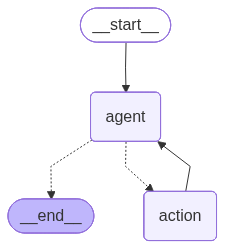

DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: continue (route to action)
DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: continue (route to action)
DEBUG: Calling Amadeus Hotel Search - City: FRA, Check-in: 2026-02-13, Check-out: 2026-02-15, Adults: 1
DEBUG: Calling Amadeus Hotel Search - City: MUC, Check-in: 2026-02-06, Check-out: 2026-02-08, Adults: 1
DEBUG: Calling Amadeus Hotel Search - City: BER, Check-in: 2026-02-13, Check-out: 2026-02-15, Adults: 1
DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: end (route to END)


system


You are a backend API.

You MUST return strictly valid JSON.
You MUST follow the exact schema provided by the user.
If data is missing, return empty arrays.
Do NOT include explanations, markdown, or extra text.
Do NOT wrap JSON in code blocks.


human


I am based in Hannover, Germany and want to plan a football-focused trip between
February 1-14, 2026.

Cities of interest:
- Munich
- Frankfurt
- Berlin

Please:
1. Find football matches I could attend in those cities
2. Identify the stadiums where the matches are played
3. Suggest train or bus travel options from Hannover to the stadiums, including departure and arrival times
4. Recommend affordable hotels near the stadiums
5. Provide stadium transport tips
6. Generate a simple travel itinerary

You MUST return the final answer as valid JSON.
Do not include explanations or markdown.
The JSON must follow this schema exactly:

{
  "matches": [
    {
      "city": "Munich",
      "date": "2026-02-07",
      "competition": "Bundesliga",
      "home_team": "Bayern Munich",
      "away_team": "Borussia Dortmund",
      "stadium": "Allianz Arena"
    }
  ],
  "transport": [
    {
      "from": "Hannover",
      "to": "Munich",
      "mode": "train",
      "departure_time": "07:30",
      "arrival_time": "11:45",
      "duration": "4h 15m"
    }
  ],
  "hotels": [
    {
      "name": "Hotel XYZ",
      "city": "Munich",
      "distance_to_stadium": "1.2 km",
      "price_estimate": "€90/night"
    }
  ],
  "stadium_tips": [
    "Arrive 90 minutes early",
    "Use U-Bahn line U6 to Allianz Arena"
  ],
  "itinerary": [
    {
      "date": "2026-02-07",
      "plan": "Morning train → hotel check-in → match → dinner"
    }
  ]
}



...

No available hotel offers found for the dates in FRA among the checked hotels.

tool

Found hotel options:
- Hotel: Berlin Marriott Hotel, Price: 801.95 EUR (approx)

ai

{
  "matches": [
    {
      "city": "Frankfurt",
      "date": "2026-02-14",
      "competition": "Bundesliga",
      "home_team": "Eintracht Frankfurt",
      "away_team": "Mönchengladbach",
      "stadium": "Deutsche Bank Park"
    },
    {
      "city": "Berlin",
      "date": "2026-02-14",
      "competition": "2. Bundesliga",
      "home_team": "Hertha Berlin",
      "away_team": "Hannover 96",
      "stadium": "Olympiastadion Berlin"
    }
  ],
  "transport": [
    {
      "from": "Hannover",
      "to": "Frankfurt",
      "mode": "train",
      "departure_time": "12:00",
      "arrival_time": "14:20",
      "duration": "2h 20m"
    },
    {
      "from": "Hannover",
      "to": "Berlin",
      "mode": "train",
      "departure_time": "11:00",
      "arrival_time": "12:30",
      "duration": "1h 30m"
    }
  ],
  "hotels": [
    {
      "name": "Berlin Marriott Hotel",
      "city": "Berlin",
      "distance_to_stadium": "3.5 km",
      "price_estimate": "€80/night"
    }
  ],
  "stadium_tips": [
    "Frankfurt Deutsche Bank Park: Easily accessible by bus, tram, and urban train network. Frankfurt am Main-Stadion train station is a 10-minute walk from the stadium.",
    "Berlin Olympiastadion: Take the S-Bahn S9 directly to Olympiastadion station. The stadium is a short walk from the station."
  ],
  "itinerary": [
    {
      "date": "2026-02-14",
      "plan": "Morning train to Berlin → hotel check-in → Hertha Berlin vs Hannover 96 match → dinner"
    },
    {
      "date": "2026-02-14",
      "plan": "Afternoon train to Frankfurt → Eintracht Frankfurt vs Mönchengladbach match → overnight stay (hotel not found)"
    }
  ]
}

In [51]:
app_sports_travel_agent = build_graph_one_tool(tools)

prompt = """
I am based in Hannover, Germany and want to plan a football-focused trip between
February 1-14, 2026.

Cities of interest:
- Munich
- Frankfurt
- Berlin

Please:
1. Find football matches I could attend in those cities
2. Identify the stadiums where the matches are played
3. Suggest train or bus travel options from Hannover to the stadiums, including departure and arrival times
4. Recommend affordable hotels near the stadiums
5. Provide stadium transport tips
6. Generate a simple travel itinerary

You MUST return the final answer as valid JSON.
Do not include explanations or markdown.
The JSON must follow this schema exactly:

{
  "matches": [
    {
      "city": "Munich",
      "date": "2026-02-07",
      "competition": "Bundesliga",
      "home_team": "Bayern Munich",
      "away_team": "Borussia Dortmund",
      "stadium": "Allianz Arena"
    }
  ],
  "transport": [
    {
      "from": "Hannover",
      "to": "Munich",
      "mode": "train",
      "departure_time": "07:30",
      "arrival_time": "11:45",
      "duration": "4h 15m"
    }
  ],
  "hotels": [
    {
      "name": "Hotel XYZ",
      "city": "Munich",
      "distance_to_stadium": "1.2 km",
      "price_estimate": "€90/night"
    }
  ],
  "stadium_tips": [
    "Arrive 90 minutes early",
    "Use U-Bahn line U6 to Allianz Arena"
  ],
  "itinerary": [
    {
      "date": "2026-02-07",
      "plan": "Morning train → hotel check-in → match → dinner"
    }
  ]
}

"""

output, history = app_call(app_sports_travel_agent, prompt)


In [52]:
import json

structured_output = json.loads(output)
structured_output

{'matches': [{'city': 'Frankfurt',
   'date': '2026-02-14',
   'competition': 'Bundesliga',
   'home_team': 'Eintracht Frankfurt',
   'away_team': 'Mönchengladbach',
   'stadium': 'Deutsche Bank Park'},
  {'city': 'Berlin',
   'date': '2026-02-14',
   'competition': '2. Bundesliga',
   'home_team': 'Hertha Berlin',
   'away_team': 'Hannover 96',
   'stadium': 'Olympiastadion Berlin'}],
 'transport': [{'from': 'Hannover',
   'to': 'Frankfurt',
   'mode': 'train',
   'departure_time': '12:00',
   'arrival_time': '14:20',
   'duration': '2h 20m'},
  {'from': 'Hannover',
   'to': 'Berlin',
   'mode': 'train',
   'departure_time': '11:00',
   'arrival_time': '12:30',
   'duration': '1h 30m'}],
 'hotels': [{'name': 'Berlin Marriott Hotel',
   'city': 'Berlin',
   'distance_to_stadium': '3.5 km',
   'price_estimate': '€80/night'}],
 'stadium_tips': ['Frankfurt Deutsche Bank Park: Easily accessible by bus, tram, and urban train network. Frankfurt am Main-Stadion train station is a 10-minute wa